In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor as KNR
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
import itertools
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

In [3]:
df = pd.read_csv("fixed_final_data_product.csv")

In [4]:
target_col = "Target_CURRENTLAPTIMEINMS"
prefixes = ['BPS', 'STS', 'BPE', 'STM', 'STE', 'THE', 'THS']

driver_input = ['BPS_SPEED', 'BPS_THROTTLE', 'BPS_STEER', 'BPS_BRAKE', 'BPS_CURRENTLAPTIMEINMS', 
             'BPS_LAPDISTANCE', 'BPS_WORLDPOSITIONX', 'BPS_WORLDPOSITIONY', 'BPE_SPEED', 'BPE_THROTTLE', 
             'BPE_STEER', 'BPE_BRAKE', 'BPE_CURRENTLAPTIMEINMS', 'BPE_LAPDISTANCE', 'BPE_WORLDPOSITIONX', 'BPE_WORLDPOSITIONY',
            'THS_SPEED', 'THS_THROTTLE', 'THS_STEER', 'THS_BRAKE', 'THS_CURRENTLAPTIMEINMS', 'THS_LAPDISTANCE', 'THS_WORLDPOSITIONX', 
             'THS_WORLDPOSITIONY', 'THE_SPEED', 'THE_THROTTLE', 'THE_STEER', 'THE_BRAKE', 'THE_CURRENTLAPTIMEINMS', 
             'THE_LAPDISTANCE', 'THE_WORLDPOSITIONX', 'THE_WORLDPOSITIONY', 'STS_SPEED', 'STS_THROTTLE', 'STS_STEER', 'STS_BRAKE', 
             'STS_CURRENTLAPTIMEINMS', 'STS_LAPDISTANCE', 'STS_WORLDPOSITIONX', 'STS_WORLDPOSITIONY', 'STM_SPEED', 'STM_THROTTLE', 
             'STM_STEER', 'STM_BRAKE', 'STM_CURRENTLAPTIMEINMS', 'STM_LAPDISTANCE', 'STM_WORLDPOSITIONX', 'STM_WORLDPOSITIONY', 
            'STE_SPEED', 'STE_THROTTLE', 'STE_STEER', 'STE_BRAKE', 'STE_CURRENTLAPTIMEINMS', 'STE_LAPDISTANCE', 'STE_WORLDPOSITIONX', 
             'STE_WORLDPOSITIONY', 'Target_CURRENTLAPTIMEINMS']

# Keep only driver related features
df = df[[col for col in driver_input if col in df.columns]]

In [5]:
def apply_iqr_filter(df, prefixes_to_clean):
    df_filtered = df.copy()
    
    for prefix in prefixes_to_clean:
        lap_col = f"{prefix}_CURRENTLAPTIMEINMS"
        
        if lap_col in df_filtered.columns:
            Q1 = df_filtered[lap_col].quantile(0.25)
            Q3 = df_filtered[lap_col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            df_filtered = df_filtered[(df_filtered[lap_col] >= lower_bound) & (df_filtered[lap_col] <= upper_bound)]
    
    return df_filtered

In [6]:
# Removing laps whose times are statistically too high
df = apply_iqr_filter(df, ['Target'])

In [7]:
# Removing rows will Null values in any column
df = df.dropna()

In [8]:
SVR_df = apply_iqr_filter(df, ['BPS', 'STM', 'STE', 'THS'])

In [9]:
def print_model_outcomes(mse, rmse, mae, r2, r2_adj):
    print(f"Lowest MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R²: {r2:.4f}")
    print(f"Adjusted R²: {r2_adj:.4f}")

In [10]:
def evaluate_model(y_true, y_pred, X_test):
    n = X_test.shape[0]
    p = X_test.shape[1]
    mse = mean_squared_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    
    return mse, rmse, mae, r2, r2_adj

In [11]:
X = SVR_df.drop(columns=target_col).copy()
y = SVR_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
svr = SVR(kernel='linear', C = 1000, epsilon= 100)
svr.fit(X_train_scaled, y_train)
y_pred = svr.predict(X_test_scaled)

mse, rmse, mae, r2, r2_adj = evaluate_model(y_test, y_pred, X_test)
print_model_outcomes(mse, rmse, mae, r2, r2_adj)

Lowest MSE: 9718.65
RMSE: 98.58
MAE: 75.68
R²: 0.9665
Adjusted R²: 0.9239


In [14]:
from scipy.optimize import differential_evolution

feature_names = list(X_train.columns)
X_bounds = []

for col in feature_names:
    lo = X_train[col].quantile(0.25)   # 25th percentile
    hi = X_train[col].quantile(0.75)   # 75th percentile
    X_bounds.append((float(lo), float(hi)))

def objective(x):
    # Convert numpy array → DataFrame with correct column names
    X_df = pd.DataFrame([x], columns=feature_names)

    # Scale using your fitted StandardScaler
    X_scaled = scaler.transform(X_df)

    # Predict using your SVR
    return float(svr.predict(X_scaled)[0])

result = differential_evolution(
    objective,
    X_bounds,
    maxiter=200,
    popsize=18,
    seed=42,
    tol=1e-3
)

best_x = result.x
best_lap = result.fun
print(best_lap)

11266.632674286204


In [38]:
for col, val in zip(feature_names, best_x):
    print(f"{col}: {val}")

BPS_SPEED: 319.09129845233275
BPS_THROTTLE: 1.0
BPS_STEER: 0.003722558752054675
BPS_BRAKE: 0.0
BPS_CURRENTLAPTIMEINMS: 3118.1070865594925
BPS_LAPDISTANCE: 249.0
BPS_WORLDPOSITIONX: 306.62131200634843
BPS_WORLDPOSITIONY: 291.5132382738897
BPE_SPEED: 172.0
BPE_THROTTLE: 0.0
BPE_STEER: 0.23959186422627698
BPE_BRAKE: 0.9024347161126987
BPE_CURRENTLAPTIMEINMS: 3714.720535851517
BPE_LAPDISTANCE: 327.8156670469712
BPE_WORLDPOSITIONX: 337.631235404835
BPE_WORLDPOSITIONY: 217.14123505927958
THS_SPEED: 152.32149113374595
THS_THROTTLE: 0.10829930353731555
THS_STEER: 0.3523384577868974
THS_BRAKE: 0.5882016410456683
THS_CURRENTLAPTIMEINMS: 4429.178256136797
THS_LAPDISTANCE: 375.777834642557
THS_WORLDPOSITIONX: 364.24064279245624
THS_WORLDPOSITIONY: 198.82234779802656
THE_SPEED: 319.0
THE_THROTTLE: 0.8899531459004079
THE_STEER: -0.002775574010812775
THE_BRAKE: 0.004709424244902275
THE_CURRENTLAPTIMEINMS: 2897.724766856489
THE_LAPDISTANCE: 275.0
THE_WORLDPOSITIONX: 304.40198894431063
THE_WORLDPOSITIO

In [15]:
left_line = pd.read_csv("f1sim-ref-left.csv")
right_line = pd.read_csv("f1sim-ref-right.csv")

In [16]:
from sklearn.neighbors import NearestNeighbors
import pandas as pd
import numpy as np

# best_x from differential evolution
best_lap_vector = best_x.reshape(1, -1)  # shape (1, n_features)

# Fit KNN on the training set (use scaled features to match SVR training)
nbrs = NearestNeighbors(n_neighbors=1, algorithm='auto').fit(X_train_scaled)

# Find the closest lap
distance, index = nbrs.kneighbors(scaler.transform(pd.DataFrame([best_x], columns=feature_names)))
closest_lap = X_train.iloc[index[0][0]]  # Series of closest lap features
print("Distance to optimized lap:", distance[0][0])

world_pos_x_cols = [col for col in X_train.columns if "WORLD_POSITIONX" in col]
world_pos_y_cols = [col.replace("X", "Y") for col in world_pos_x_cols]

closest_lap_df = pd.DataFrame([closest_lap])

Distance to optimized lap: 3.859197495613724


In [17]:
true_lap_time = y_train.iloc[index[0][0]]
print("Actual lap time of closest lap:", true_lap_time)

Actual lap time of closest lap: 12437


In [18]:
print("Closest lap features:")
for col, val in closest_lap.items():
    print(f"{col}: {val}")

Closest lap features:
BPS_SPEED: 322.0
BPS_THROTTLE: 0.9486871478966408
BPS_STEER: 0.0012156554347895
BPS_BRAKE: 0.0
BPS_CURRENTLAPTIMEINMS: 2916.0
BPS_LAPDISTANCE: 255.0
BPS_WORLDPOSITIONX: 296.6845736917118
BPS_WORLDPOSITIONY: 290.8754711224435
BPE_SPEED: 208.0
BPE_THROTTLE: 0.0
BPE_STEER: 0.0961523198413835
BPE_BRAKE: 0.8812348614459856
BPE_CURRENTLAPTIMEINMS: 4029.0
BPE_LAPDISTANCE: 339.0
BPE_WORLDPOSITIONX: 356.6274230989136
BPE_WORLDPOSITIONY: 231.9842854368036
THS_SPEED: 166.0
THS_THROTTLE: 0.1231241213374785
THS_STEER: 0.3023625233872287
THS_BRAKE: 0.0285495336384516
THS_CURRENTLAPTIMEINMS: 4651.0
THS_LAPDISTANCE: 370.0
THS_WORLDPOSITIONX: 373.59079153492354
THS_WORLDPOSITIONY: 204.95470617538447
THE_SPEED: 322.0
THE_THROTTLE: 0.896082815043484
THE_STEER: 0.0012210612393749
THE_BRAKE: 0.012129603824024
THE_CURRENTLAPTIMEINMS: 2927.0
THE_LAPDISTANCE: 256.0
THE_WORLDPOSITIONX: 297.4105824872618
THE_WORLDPOSITIONY: 290.18727624429295
STS_SPEED: 270.0
STS_THROTTLE: 0.0
STS_STEER: 0

In [28]:
# Difference in optimal and closest lap values
for col, opt_val, true_val in zip(feature_names, best_x, closest_lap):
    diff = opt_val - true_val
    print(f"{col}: {diff}")

BPS_SPEED: -2.908701547667249
BPS_THROTTLE: 0.05131285210335923
BPS_STEER: 0.002506903317265175
BPS_BRAKE: 0.0
BPS_CURRENTLAPTIMEINMS: 202.10708655949247
BPS_LAPDISTANCE: -6.0
BPS_WORLDPOSITIONX: 9.936738314636614
BPS_WORLDPOSITIONY: 0.6377671514462122
BPE_SPEED: -36.0
BPE_THROTTLE: 0.0
BPE_STEER: 0.14343954438489348
BPE_BRAKE: 0.021199854666713036
BPE_CURRENTLAPTIMEINMS: -314.27946414848293
BPE_LAPDISTANCE: -11.184332953028786
BPE_WORLDPOSITIONX: -18.99618769407857
BPE_WORLDPOSITIONY: -14.843050377524008
THS_SPEED: -13.678508866254049
THS_THROTTLE: -0.014824817800162954
THS_STEER: 0.04997593439966869
THS_BRAKE: 0.5596521074072167
THS_CURRENTLAPTIMEINMS: -221.82174386320276
THS_LAPDISTANCE: 5.777834642557025
THS_WORLDPOSITIONX: -9.350148742467297
THS_WORLDPOSITIONY: -6.132358377357917
THE_SPEED: -3.0
THE_THROTTLE: -0.006129669143076111
THE_STEER: -0.0039966352501876745
THE_BRAKE: -0.007420179579121724
THE_CURRENTLAPTIMEINMS: -29.27523314351083
THE_LAPDISTANCE: 19.0
THE_WORLDPOSITIONX: 

In [19]:
# Make a DataFrame from the DE result
best_x_df = pd.DataFrame([best_x], columns=feature_names)

# Identify WORLD_POSITION columns
world_pos_x_cols = [col for col in feature_names if "WORLD_POSITIONX" in col]
world_pos_y_cols = [col.replace("X", "Y") for col in world_pos_x_cols]

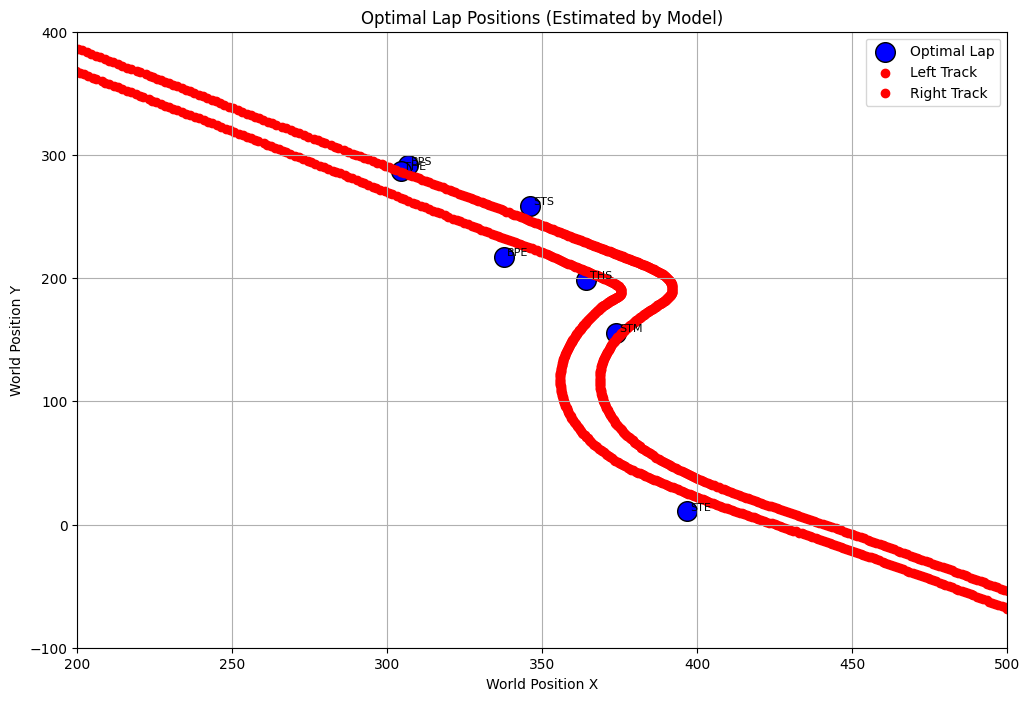

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Extract X/Y columns
world_pos_x_cols = [col for col in best_x_df.columns if "WORLDPOSITIONX" in col]
world_pos_y_cols = [col.replace("X", "Y") for col in world_pos_x_cols]

# Extract values and ensure numeric
x_vals = best_x_df[world_pos_x_cols].astype(float).values.flatten()
y_vals = best_x_df[world_pos_y_cols].astype(float).values.flatten()

# Check if arrays are empty
if len(x_vals) == 0 or len(y_vals) == 0:
    raise ValueError("No WORLD_POSITIONX/Y values found to plot.")

plt.figure(figsize=(12,8))

# Plot points only (no connecting lines)
plt.scatter(x_vals, y_vals, s=200, c='blue', edgecolors='black', label='Optimal Lap')

# Label each point
for i, (x, y) in enumerate(zip(x_vals, y_vals)):
    plt.text(x + 1, y + 1, world_pos_x_cols[i].replace("_WORLDPOSITIONX",""), fontsize=8)

plt.scatter(left_line["WORLDPOSX"], left_line["WORLDPOSY"], c='red', label='Left Track')
plt.scatter(right_line["WORLDPOSX"], right_line["WORLDPOSY"], c='red', label='Right Track')
plt.xlabel("World Position X")
plt.ylabel("World Position Y")
plt.title("Optimal Lap Positions (Estimated by Model)")
plt.grid(True)
plt.xlim(200, 500)
plt.ylim(-100, 400)

plt.legend()
plt.show()

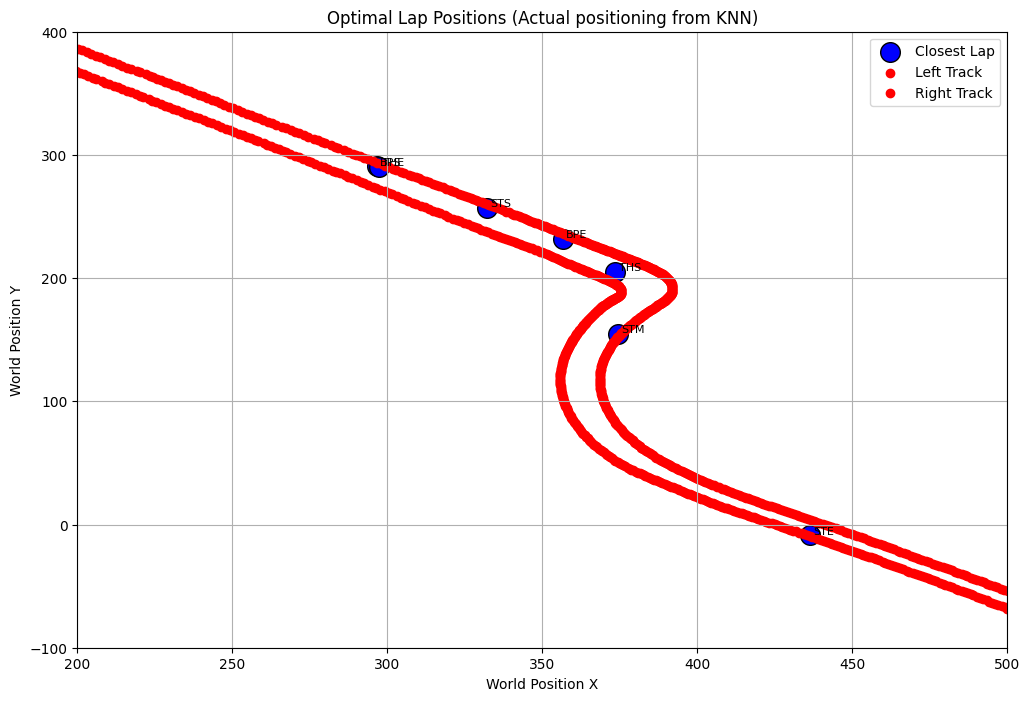

In [22]:
# Conversion
closest_lap_df = closest_lap.to_frame().T 

# Extract X/Y columns
world_pos_x_cols = [col for col in closest_lap_df.columns if "WORLDPOSITIONX" in col]
world_pos_y_cols = [col.replace("X", "Y") for col in world_pos_x_cols]

# Extract values and ensure numeric
x_vals = closest_lap_df[world_pos_x_cols].astype(float).values.flatten()
y_vals = closest_lap_df[world_pos_y_cols].astype(float).values.flatten()

# Check if arrays are empty
if len(x_vals) == 0 or len(y_vals) == 0:
    raise ValueError("No WORLD_POSITIONX/Y values found to plot.")

plt.figure(figsize=(12,8))

# Plot points only (no connecting lines)
plt.scatter(x_vals, y_vals, s=200, c='blue', edgecolors='black', label='Closest Lap')

# Label each point
for i, (x, y) in enumerate(zip(x_vals, y_vals)):
    plt.text(x + 1, y + 1, world_pos_x_cols[i].replace("_WORLDPOSITIONX",""), fontsize=8)

plt.scatter(left_line["WORLDPOSX"], left_line["WORLDPOSY"], c='red', label='Left Track')
plt.scatter(right_line["WORLDPOSX"], right_line["WORLDPOSY"], c='red', label='Right Track')
plt.xlabel("World Position X")
plt.ylabel("World Position Y")
plt.title("Optimal Lap Positions (Actual positioning from KNN)")
plt.grid(True)
plt.xlim(200, 500)
plt.ylim(-100, 400)

plt.legend()
plt.show()

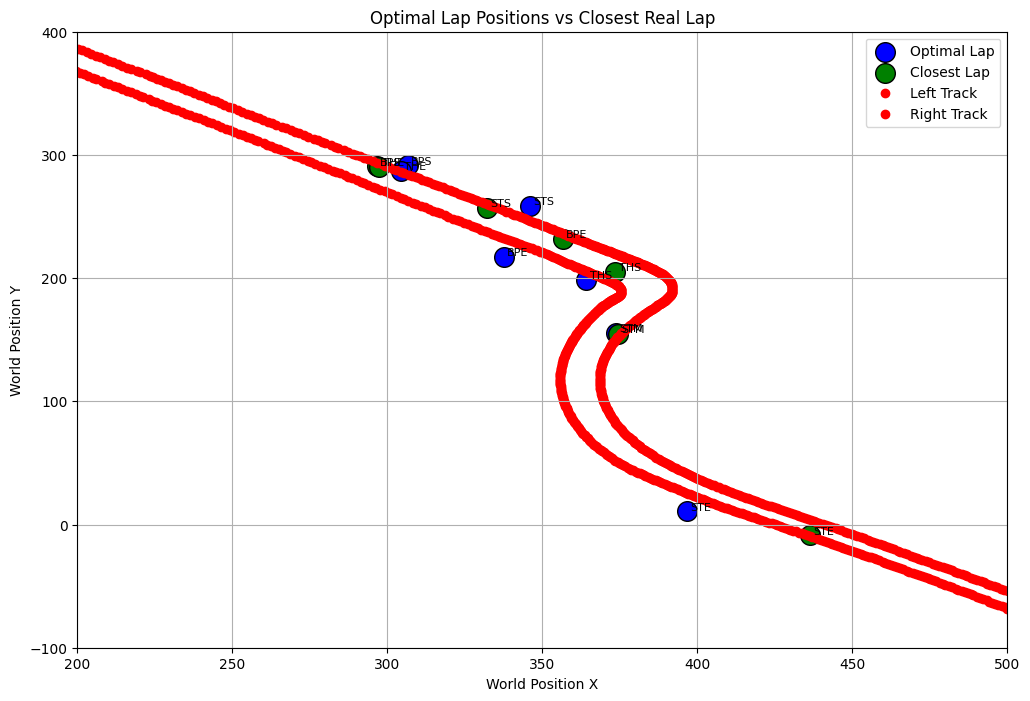

In [26]:
# Combine KNN and Optimal 
# Plot the track first 

# Plot optimal
# Extract X/Y columns
world_pos_x_cols = [col for col in best_x_df.columns if "WORLDPOSITIONX" in col]
world_pos_y_cols = [col.replace("X", "Y") for col in world_pos_x_cols]

# Extract values and ensure numeric
x_vals = best_x_df[world_pos_x_cols].astype(float).values.flatten()
y_vals = best_x_df[world_pos_y_cols].astype(float).values.flatten()

# Check if arrays are empty
if len(x_vals) == 0 or len(y_vals) == 0:
    raise ValueError("No WORLD_POSITIONX/Y values found to plot.")

plt.figure(figsize=(12,8))

# Plot points only (no connecting lines)
plt.scatter(x_vals, y_vals, s=200, c='blue', edgecolors='black', label='Optimal Lap')

# Label each point
for i, (x, y) in enumerate(zip(x_vals, y_vals)):
    plt.text(x + 1, y + 1, world_pos_x_cols[i].replace("_WORLDPOSITIONX",""), fontsize=8)

# Plot closest real track
# Conversion
closest_lap_df = closest_lap.to_frame().T 

# Extract X/Y columns
world_pos_x_cols = [col for col in closest_lap_df.columns if "WORLDPOSITIONX" in col]
world_pos_y_cols = [col.replace("X", "Y") for col in world_pos_x_cols]

# Extract values and ensure numeric
x_vals = closest_lap_df[world_pos_x_cols].astype(float).values.flatten()
y_vals = closest_lap_df[world_pos_y_cols].astype(float).values.flatten()

# Check if arrays are empty
if len(x_vals) == 0 or len(y_vals) == 0:
    raise ValueError("No WORLD_POSITIONX/Y values found to plot.")

# Plot points only (no connecting lines)
plt.scatter(x_vals, y_vals, s=200, c='green', edgecolors='black', label='Closest Lap')

# Label each point
for i, (x, y) in enumerate(zip(x_vals, y_vals)):
    plt.text(x + 1, y + 1, world_pos_x_cols[i].replace("_WORLDPOSITIONX",""), fontsize=8)

plt.scatter(left_line["WORLDPOSX"], left_line["WORLDPOSY"], c='red', label='Left Track')
plt.scatter(right_line["WORLDPOSX"], right_line["WORLDPOSY"], c='red', label='Right Track')
plt.xlabel("World Position X")
plt.ylabel("World Position Y")
plt.title("Optimal Lap Positions vs Closest Real Lap")
plt.grid(True)
plt.xlim(200, 500)
plt.ylim(-100, 400)

plt.legend()
plt.show()

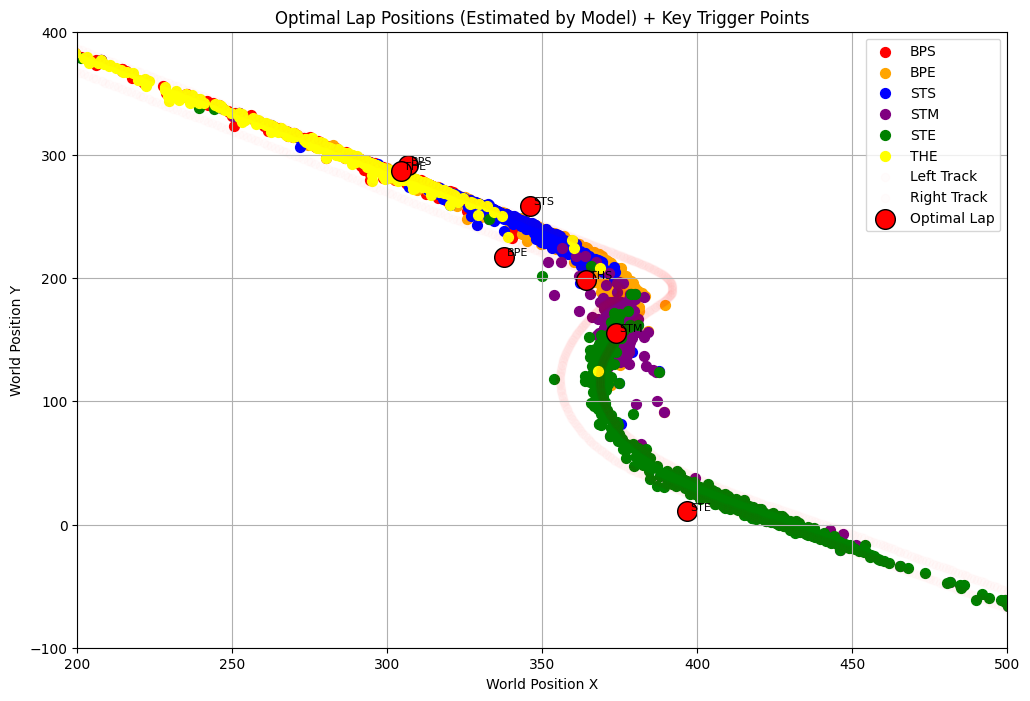

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Extract X/Y columns
world_pos_x_cols = [col for col in best_x_df.columns if "WORLDPOSITIONX" in col]
world_pos_y_cols = [col.replace("X", "Y") for col in world_pos_x_cols]

# Extract values and ensure numeric
x_vals = best_x_df[world_pos_x_cols].astype(float).values.flatten()
y_vals = best_x_df[world_pos_y_cols].astype(float).values.flatten()

# Check if arrays are empty
if len(x_vals) == 0 or len(y_vals) == 0:
    raise ValueError("No WORLD_POSITIONX/Y values found to plot.")

plt.figure(figsize=(12,8))
lap_df = df

# Mark key moments
moments = ['BPS', 'BPE', 'STS', 'STM', 'STE','THE' ,'THS']
colors = ['red', 'orange', 'blue', 'purple', 'green', 'yellow']

for m, c in zip(moments, colors):
    x = lap_df[f'{m}_WORLDPOSITIONX']
    y = lap_df[f'{m}_WORLDPOSITIONY']
    plt.scatter(x, y, color=c, label=m, s=50)

plt.scatter(left_line["WORLDPOSX"], left_line["WORLDPOSY"], c='red', alpha=0.01, label='Left Track')
plt.scatter(right_line["WORLDPOSX"], right_line["WORLDPOSY"], c='red', alpha=0.01, label='Right Track')

# Plot points only (no connecting lines)
plt.scatter(x_vals, y_vals, s=200, c='red', edgecolors='black', label='Optimal Lap')

# Optional: label each point
for i, (x, y) in enumerate(zip(x_vals, y_vals)):
    plt.text(x + 1, y + 1, world_pos_x_cols[i].replace("_WORLDPOSITIONX",""), fontsize=8)
    
plt.xlabel("World Position X")
plt.ylabel("World Position Y")
plt.title("Optimal Lap Positions (Estimated by Model) + Key Trigger Points")
plt.grid(True)
plt.xlim(200, 500)
plt.ylim(-100, 400)

plt.legend()
plt.show()